In [1]:
# %% 
import os
import pathlib
import sys

# Save the starting directory
original_dir = pathlib.Path.cwd()
print("Starting in:", original_dir)

# Move to the model folder
os.chdir("models/point_MAE")
print("Now in:", pathlib.Path.cwd())

# %% Model and utility imports
import types
import torch

# From your project
from utils.config import get_config
from models import build_model_from_cfg
from tools.builder import model_builder, load_model

CFG_PATH  = "cfgs/pretrain.yaml"
CKPT_PATH = "models/checkpoints/pretrain.pth"

# Setup arguments for configuration
args = types.SimpleNamespace(
    config=CFG_PATH,
    resume=False,
    log_name="load_only",
    experiment_path=".", tfboard_path=".",
    launcher="none", distributed=False, local_rank=0,
    test=True, finetune_model=False, scratch_model=False,
    deterministic=False, seed=None, num_workers=4,
    shot=-1, way=None, fold=None, ckpts=None,
)

# Load config
config = get_config(args, logger=None)
print("✅ Config loaded successfully")

# Build model from config
model = model_builder(config.model)

# Move to GPU if available
if torch.cuda.is_available():
    model = model.cuda()

# Load pretrained weights
load_model(model, CKPT_PATH, logger=None)

# Set to evaluation mode
model.eval()

print("✅ Pretrained Point-MAE model loaded and ready for inference.")
# %% Dataset Path Handling and Function Imports
os.chdir(original_dir)
print("Now in:", pathlib.Path.cwd())

Starting in: c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE
Now in: c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\models\point_MAE


2025-11-04 22:51:42,691 - Point_MAE - INFO - [Point_MAE] 
2025-11-04 22:51:42,691 - Transformer - INFO - [args] {'mask_ratio': 0.6, 'mask_type': 'rand', 'trans_dim': 384, 'encoder_dims': 384, 'depth': 12, 'drop_path_rate': 0.1, 'num_heads': 6, 'decoder_depth': 4, 'decoder_num_heads': 6}


Copy the Config file from cfgs/pretrain.yaml to .\config.yaml
✅ Config loaded successfully


2025-11-04 22:51:42,896 - Point_MAE - INFO - [Point_MAE] divide point cloud into G64 x S32 points ...


Loading weights from models/checkpoints/pretrain.pth...
ckpts @ 300 epoch( performance = {'acc': 0.0})
✅ Pretrained Point-MAE model loaded and ready for inference.
Now in: c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE


In [2]:
# %%
import os
import os.path as osp

# ROOT = project root two levels above current folder (adjust if needed)
ROOT = pathlib.Path.cwd()
print("Project ROOT:", ROOT)

# Optional: verify it contains expected subfolders
print("Subfolders in ROOT:", os.listdir(ROOT))


Project ROOT: c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE
Subfolders in ROOT: ['.vscode', 'build_shapenetlike_dataset.ipynb', 'extracted_features', 'models', 'pointmae_TSNE.ipynb', 'pointnet_TSNE.ipynb', 'shapenet_like_out', 'UTILS', '__pycache__']


In [3]:
# extra imports you likely need up top
import os.path as osp
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
utils_path = osp.join(ROOT, "UTILS")
from UTILS.shapenet_dataset import ShapenetDataset

# ---------- helpers to access encoder tokens (no masking at inference) ----------
def _has_forward_encoder(m):
    return any(hasattr(m, a) for a in ['forward_encoder', 'encode', 'forward_features'])

@torch.no_grad()
def _call_encoder_only(m, x):
    """
    Try common encoder-only entrypoints with mask_ratio=0.0.
    Returns tokens of shape (B, P, C) or (P, C) if B=1.
    """
    if hasattr(m, 'forward_encoder'):
        out = m.forward_encoder(x, mask_ratio=0.0)
        return out[0] if isinstance(out, (tuple, list)) else out
    if hasattr(m, 'encode'):
        return m.encode(x)
    if hasattr(m, 'forward_features'):
        return m.forward_features(x)
    raise AttributeError("No encoder-only forward found on the model.")

def _find_encoder_module(m):
    for name in ['encoder', 'transformer_encoder', 'blocks', 'enc']:
        if hasattr(m, name):
            return getattr(m, name)
    # fallback: first big child
    for _, ch in m.named_children():
        if isinstance(ch, torch.nn.Module):
            return ch
    raise AttributeError("Could not locate an encoder-like submodule.")

@torch.no_grad()
def _encoder_tokens_via_hook(m, x):
    enc = _find_encoder_module(m)
    bucket = {}
    def hook_fn(_, __, out):
        bucket['tokens'] = out
    h = enc.register_forward_hook(hook_fn)
    try:
        _ = m(x)  # run full forward once; hook captures encoder output
    finally:
        h.remove()
    if 'tokens' not in bucket:
        raise RuntimeError("Encoder hook did not capture tokens; inspect model forward.")
    return bucket['tokens'][0] if isinstance(bucket['tokens'], (tuple, list)) else bucket['tokens']

# ------------------ main API ------------------
def _unit_sphere(x):  # normalize each cloud to unit sphere
    c = x.mean(1, keepdim=True)
    r = torch.quantile(torch.norm(x - c, dim=2), 0.95, dim=1, keepdim=True).unsqueeze(-1)
    return (x - c) / torch.clamp(r, 1e-6)

@torch.no_grad()
def analyse_pointMAE_backbone(model, device, npoints=10000, plots=True):
    torch.manual_seed(42)
    np.random.seed(42)

    # Dataset setup
    ROOT_dataset = osp.join(ROOT, "shapenet_like_out")
    ds = ShapenetDataset(ROOT_dataset, npoints=npoints, split="test", classification=True, normalize=False)
    dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

    model.eval()

    feats, labels = [], []

    # ---- FEATURE EXTRACTION ----
    for batch in dl:
        # Try to unpack common dataset formats
        if isinstance(batch, (list, tuple)):
            # heuristics: look for the point cloud tensor (B, N, 3) and a label tensor
            pts = None
            lbl = None
            for b in batch:
                if isinstance(b, torch.Tensor):
                    if b.dim() == 3 and b.size(-1) == 3:
                        pts = b
                    elif b.dim() == 1:
                        lbl = b
            if pts is None:
                raise ValueError("Could not find (B,N,3) points in batch.")
            if lbl is None:
                # fallback to zeros if labels not provided
                lbl = torch.zeros(pts.size(0), dtype=torch.long)
        elif isinstance(batch, dict):
            pts = batch.get('points') or batch.get('data') or batch.get('x')
            lbl = batch.get('label') or batch.get('y') or torch.zeros(len(pts), dtype=torch.long)
            if pts is None:
                raise ValueError("Dict batch missing 'points'/'data'/'x'.")
        else:
            raise ValueError("Unrecognized batch format from DataLoader.")

        pts = pts.to(device).float()  # (B, N, 3)
        # optional normalization (dataset.normalize=False above)
        pts = _unit_sphere(pts)

        # Inference through encoder only (no masking)
        try:
            tokens = _call_encoder_only(model, pts)   # (B, P, C)
            print("encoder only")
             
        except Exception:
            tokens = _encoder_tokens_via_hook(model, pts)
            print("hooks")

        if tokens.dim() == 2:  # (P, C) -> add batch
            tokens = tokens.unsqueeze(0)
        # mean-pool tokens per sample -> (B, C)
        feat_b = tokens.mean(dim=1).detach().cpu().numpy()
        feats.append(feat_b)

        labels.append(lbl.detach().cpu().numpy())

    X = np.vstack(feats)                      # (num_samples, C)
    y = np.concatenate(labels).astype(int)    # (num_samples,)
    print(f"[PointMAE-pretrain] features: {X.shape}, labels: {y.shape}")

    # Saving extracted features
    save_dir = osp.join(ROOT, "extracted_features", "PointMAE_pretrain")
    os.makedirs(save_dir, exist_ok=True)
    df = pd.DataFrame(X, columns=[f"feat_{i:04d}" for i in range(X.shape[1])])

    # Get dataset names and labels
    names = [osp.splitext(osp.basename(seg))[0] for *_, seg, _ in ds.datapath]
    n = min(len(df), len(names), len(y))
    df = df.iloc[:n].copy()
    df.insert(0, "foil_name", names[:n])
    df.insert(1, "label", y[:n])

    # Output paths
    out_csv  = osp.join(save_dir, "pointmae_features.csv")
    out_parq = osp.join(save_dir, "pointmae_features.parquet")
    df.to_csv(out_csv, index=False)
    try:
        df.to_parquet(out_parq, index=False)
    except Exception as e:
        print(f"[{model}] Parquet save skipped ({e}).")

    # Plot features if required
    if plots:
        try:
            import sys
            sys.path.append(str(ROOT / 'utils'))
            from UTILS.plot_tsne import plot_extracted_features_tsne
            plot_extracted_features_tsne(X, ds, "PointMAE_pretrain", save_dir=save_dir, perplexity = 30.0)
        except Exception as e:
            print(f"[PointMAE-pretrain] plotting skipped: {e}")

    return {"model_name": "PointMAE_pretrain", "features": X, "labels": y}


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
hooks
[PointMAE-pretrain] features: (1000, 384), labels: (1000,)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.016s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000937
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.526131
[t-SNE] KL divergence after 1000 iterations: 1.321174
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain_tsne_embeddings.npy → c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4Surogate

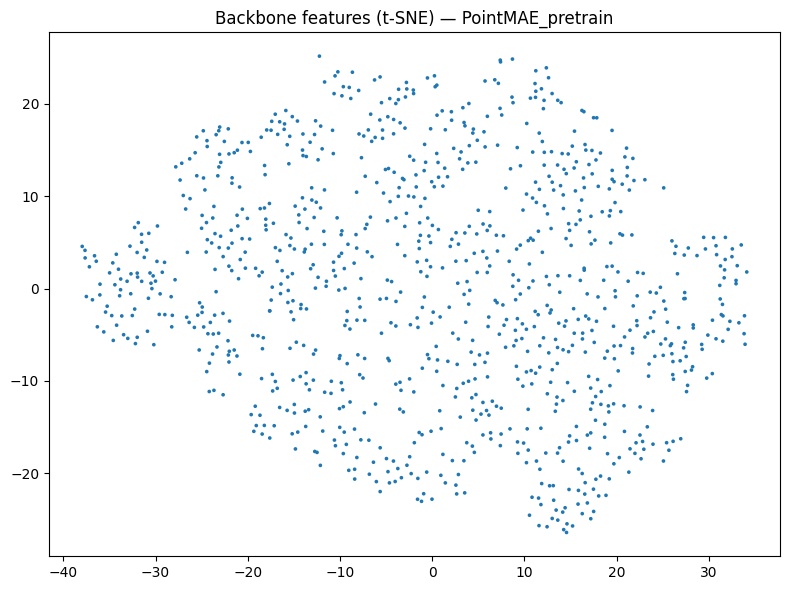

[PointMAE_pretrain] DBSCAN: clusters=3, noise=19 (eps=3.0, min_samples=10)
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_dbscan.png


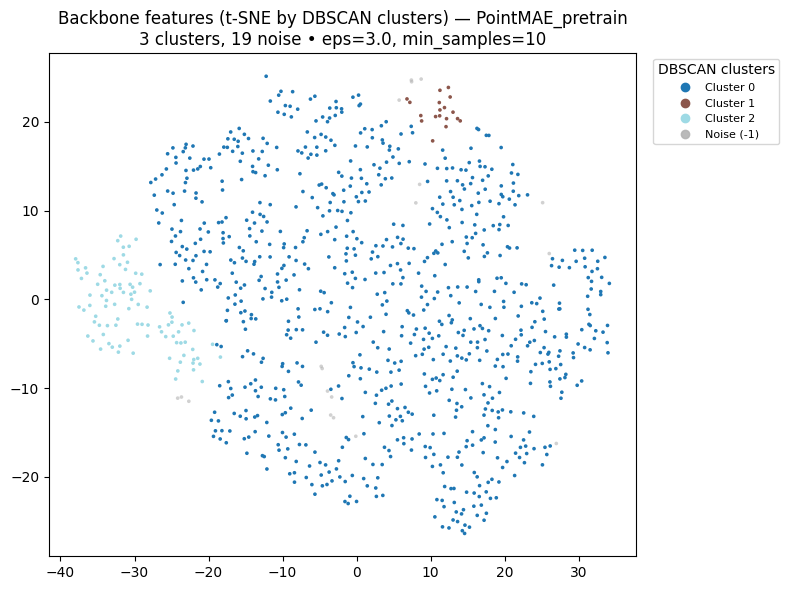

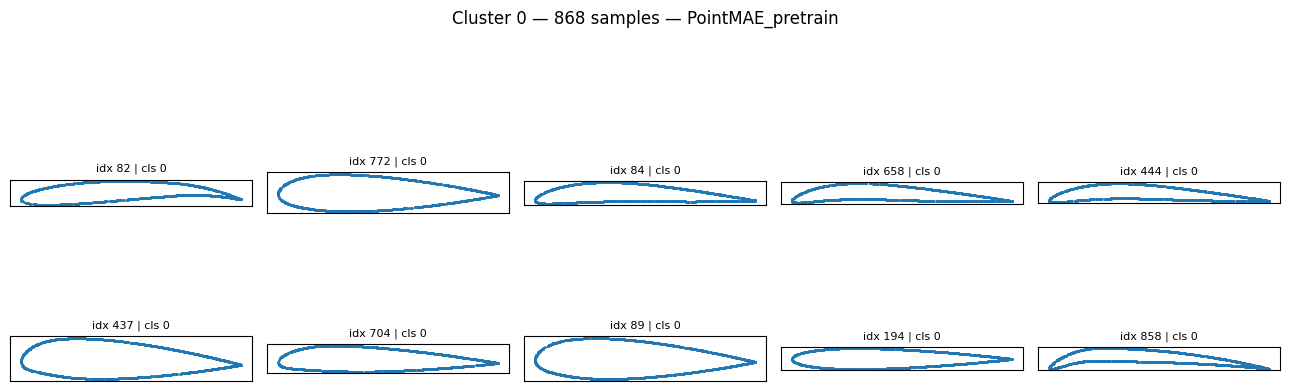

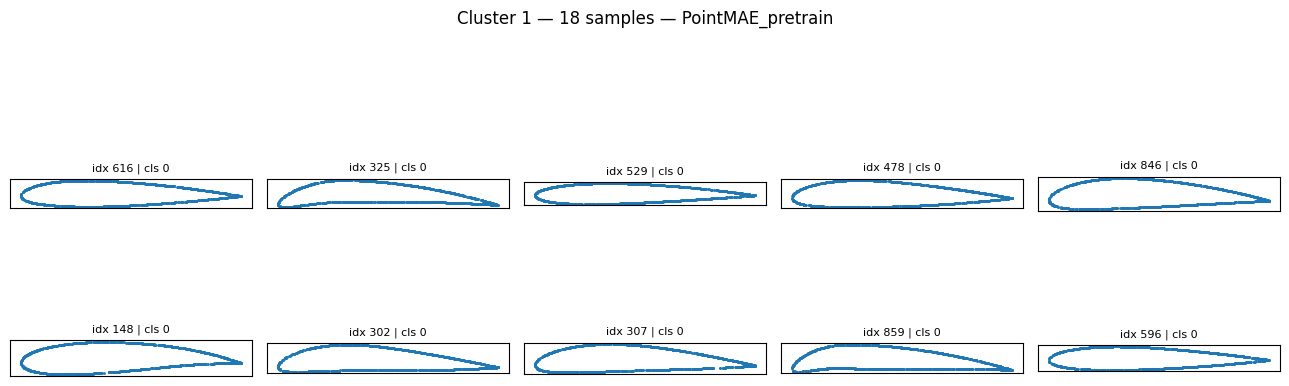

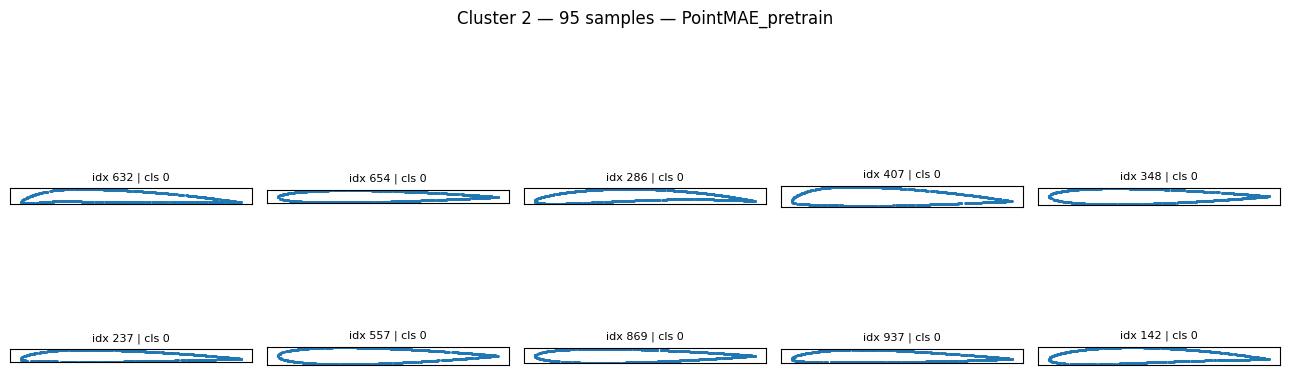

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_area.png


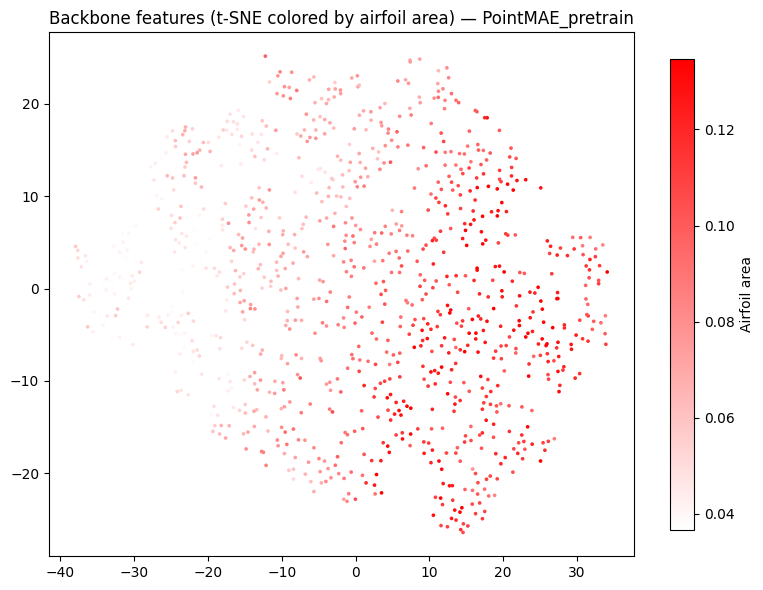

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_camber.png


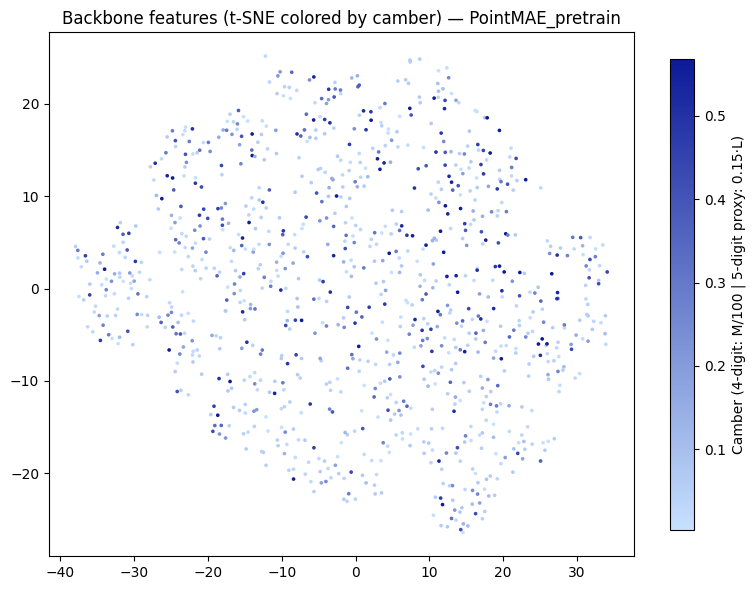

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_thickness.png


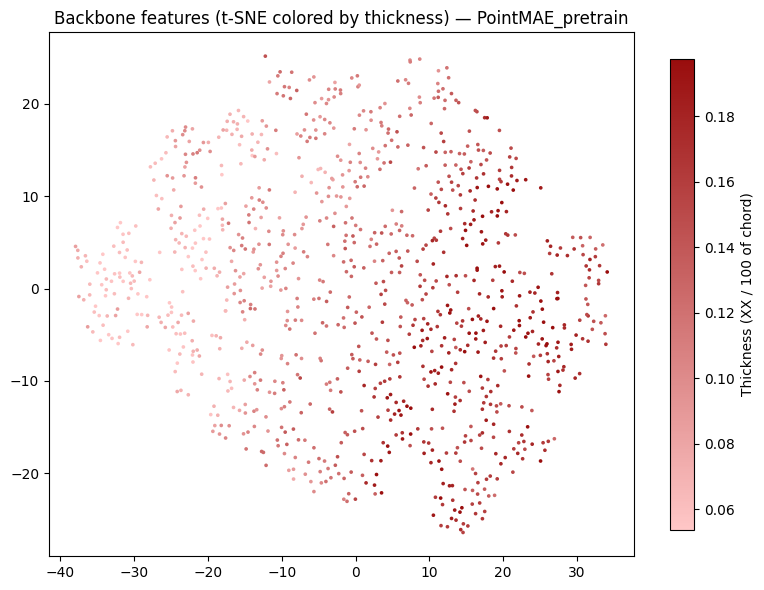

In [4]:
# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Run feature extraction on the test split
result = analyse_pointMAE_backbone(
    model=model,
    device=device,
    npoints=1024,   # number of sampled points per shape; 1024 typical for Point-MAE
    plots=True      # set False to skip t-SNE plotting
)